In [1]:
import numpy as np
import matplotlib.pyplot as plt
from my_functions import build_poly_features, logregression_GD, plot_logregression_regions
import pandas as pd

# Softmax Regression
(multiclass logistic regression)

Today: $k$ classes $(0,1,2,\ldots,k-1)$.

data: $X$ with $m$ rows (data points) and $n$ columns (features).

 $y$ contains the classes for each data point
      
goal: For each data point $x[i]$, we want to estimate $P_{ij}=$ probability that $x[i]$ belongs to class $j$.

**The Softmax Function**

Given the $i$th data point, we need to compute $P_{ij} = \frac{e^{x[i]\theta_j}} {\sum_{j=0}^{k-1}e^{x[i]\theta j}} $ for all $j\in\{0,1,\ldots,n-1\}$.

Our function satisfies $\sigma([x],[\theta_0|\theta_1|\ldots|\theta_{k-1}]) = [P]$

How does $\sigma$ work?

1. multiply $X$ by $\theta$
2. apply $e^t$ to every entry of $X\theta$
3. normalize rows so that they add to one.


We'll also be using one-hot encoding, turning $y$ into an $m\times k$ 0/1-valued row stochastic matrix $Y$.

Now, we need to find a matrix $\theta$ such that $P\approx Y$.

cost function: $E(\theta) = -\sum_{i=1}^m\sum_{j=0}^{k-1}Y_{ij}\log P_{ij}$

$E(\theta)$ penalizes wrong predictions. If $Y_{ij}=1$ but $P_{ij}\approx 0$, then $-Y_{ij}\log P_{ij}>>1$.


REMARK: Softmax reg with k=2 is logistic regression

gradient:

$\nabla E = X^T(\sigma(X,\theta) - Y)$.

****

In [2]:
# one-hot encoding function

def one_hot_encoding(v):
    cat = np.unique(v)
    dic_cat = {cat[i] : i for i in range(len(cat))}
    v_ord = [dic_cat[v[i]] for i in range(len(v))]
    V = np.zeros((len(v),len(cat)))
    V[np.arange(len(v)),v_ord]=1
    return V,cat

In [3]:
y = ['Spain','Italy','Italy','USA','Italy']
Y=one_hot_encoding(y)[0]

In [4]:
# softmax function
X = np.random.randn(5,2)
theta = np.random.randn(2,3)
P = np.exp(X.dot(theta))
row_sum = np.sum(P,axis=1).reshape(-1,1)
P = P/row_sum

In [5]:
def softmax(X,theta):
    P = np.exp(X.dot(theta))
    row_sum = np.sum(P,axis=1).reshape(-1,1)
    return P/row_sum

In [6]:
# cost function E(theta)
def softmax_cost(X,Y,theta):
    P = softmax(X,theta)
    return -np.sum(Y*np.log(P))

In [7]:
softmax_cost(X,Y,theta)

8.205381250813678

In [8]:
# gradient descent
def softmaxregression_GD(X,y,learning_rate,epochs):
    def softmax(X,theta):
        P = np.exp(X.dot(theta))
        row_sum = np.sum(P,axis=1).reshape(-1,1)
        return P/row_sum
    def softmax_cost(X,Y,theta):
        P = softmax(X,theta)
        return -np.sum(Y*np.log(P))
    
    def one_hot_encoding(v):
        cat = np.unique(v)
        dic_cat = {cat[i] : i for i in range(len(cat))}
        v_ord = [dic_cat[v[i]] for i in range(len(v))]
        V = np.zeros((len(v),len(cat)))
        V[np.arange(len(v)),v_ord]=1
        return V,cat
    
    # shape of X
    m,n = X.shape
    
    #one-hot encoding
    Y,labels = one_hot_encoding(y)
    
    # number of classes
    k = len(labels)
    
    #initialize theta vector
    theta = np.random.randn(n,k)
    
    # initialize cost vector
    cost = np.zeros(epochs)
    
    # gradient descent iterations
    for epoch in range(epochs):
        gradient = X.T.dot(softmax(X,theta)-Y)
        theta = theta - learning_rate*gradient
        cost[epoch] = softmax_cost(X,Y,theta)
    return theta, cost, labels

In [9]:
## Example: the iris dataset

url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice-bis/master/Data/iris.csv'


In [10]:
data = pd.read_csv(url)
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [11]:
# there are three species of iris: versicolor, setosa, and virginica

#target vector
y= data['species'].to_numpy()

In [12]:
#feature matrix X
X=data[['sepal_length','sepal_width','petal_length','petal_width']].to_numpy()

In [14]:
# optional: add bias (the column of all ones) and/or polynomial features
from my_functions import build_poly_features
X=build_poly_features(X,degree=1)

In [15]:
# training-test split (75% / 25%)

m = len(y)

permutation = np.random.permutation(m)

X = X[permutation]
y=y[permutation]

X_train, y_train = X[0:3*m//4],y[0:3*m//4]
X_test, y_test = X[3*m//4:m],y[3*m//4:m]

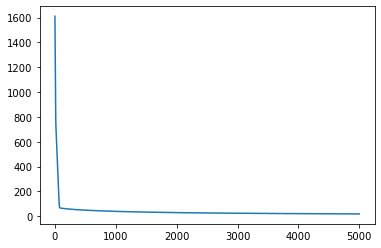

In [18]:
# gradient descent

theta,cost,labels = softmaxregression_GD(X_train,y_train,learning_rate=0.0001,epochs=5000)
plt.plot(cost)

In [21]:
# test the classifier

def softmax_predictor(X,theta,labels):
    P = softmax(X,theta)

    return labels[np.argmax(P,axis = 1)]

In [22]:
y_test_pred = softmax_predictor(X_test,theta,labels)

In [24]:
# percentage of correct classifications

np.mean(y_test == y_test_pred)

0.9736842105263158

In [29]:
# confusion matrix

# C[i,j] is the number of class-i points classified as class-j

def confusion_matrix(y,y_pred,labels):
    
    C = np.zeros((len(labels),len(labels)))
    
    for i, label_i in enumerate(labels):
        for j, label_j in enumerate(labels):
            C[i,j] = np.sum(y_pred[y==label_i]==label_j)
            
    return C

In [30]:
confusion_matrix(y_test,y_test_pred,labels)

array([[15.,  0.,  0.],
       [ 0., 13.,  1.],
       [ 0.,  0.,  9.]])

## spirals dataset

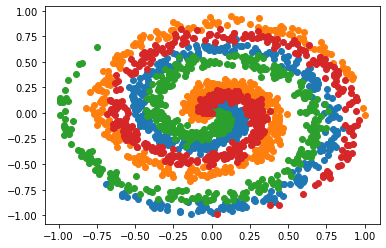

In [31]:
classes = 4
n_points = 500
noise = 0.35
radius = 10

X = np.zeros((n_points*classes, 2))
y = np.zeros(n_points*classes).astype('int')

for class_number in range(classes):
    ix = range(n_points*class_number, n_points*(class_number+1))
    r = np.linspace(0,1, n_points)
    t = np.linspace(class_number*radius, (class_number+1)*radius, n_points) + np.random.randn(n_points)*noise
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = class_number
    
    
for i in range(classes):
    
    plt.plot(X[y==i,0],X[y==i,1],'o', label = 'class'+str(i))

In [52]:
d=10

X_poly = build_poly_features(X,degree=d)

In [53]:
def plot_softmax_regions(X, y, theta, labels, degree=1):
    from matplotlib.colors import ListedColormap
    
    # softmax predictor function
    def predictor_softmax(X,theta,labels):
        P = softmax(X,theta)
        return labels[np.argmax(P,axis=1)]
    
    # create a 500x500 meshgrid
    m_plot = 500
    x1 = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, m_plot)
    x2 = np.linspace(X[:,1].min()-0.5,X[:,1].max()+0.5, m_plot)
    X1, X2 = np.meshgrid(x1, x2) 
    X_plot = np.c_[X1.ravel(), X2.ravel()]
    
    # add polynomial features
    X_plot_poly = build_poly_features(X_plot,degree=degree)

    # evaluate the softmax regression model at each point of the mesh grid    
    y_plot = predictor_softmax(X_plot_poly,theta,labels).reshape(X1.shape)        


    # custom color map
    k = len(labels)
    custom_cmap = ListedColormap(['C'+str(i) for i in range(k)])
    
    # softmax classification regions
    plt.figure(figsize=(12,5))
    plt.contourf(X1, X2, y_plot, alpha=0.3, cmap=custom_cmap)
    
    # plot data points
    for label in labels:
        plt.scatter(X[y==label,0],X[y==label,1], label=label)
        
    plt.legend(fontsize=15)

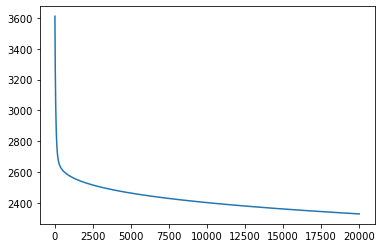

In [58]:
theta,cost,labels = softmaxregression_GD(X_poly, y,learning_rate=0.0001, epochs = 20000)

plt.plot(cost)

<ipython-input-5-25b2b8b8cbc5>:2: RuntimeWarning: overflow encountered in exp
  P = np.exp(X.dot(theta))
<ipython-input-5-25b2b8b8cbc5>:4: RuntimeWarning: invalid value encountered in true_divide
  return P/row_sum


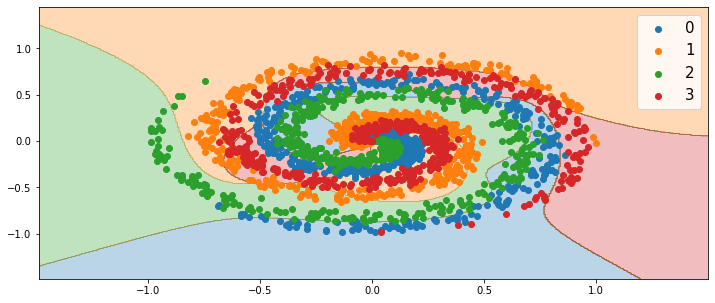

In [59]:
plot_softmax_regions(X, y, theta, labels, degree=d)